## Sampling and Random Numbers

## Intro

- Uncertainty is at the core of probability: How do we quantify and manage risk?
- The paradox is, we want a consistent answer to emerge out of randomized experiments, to be sure that our answers don't depend on chance
- We often want to test our ideas on randomness that we can control and manipulate
- Numpy gives us tools to generate random vectors (a **sample**), and we'll use them frequently through the course

## Random Sample

- A **random sample** is a collection of $n$ random vectors, $[X_1, X_2, ..., X_n]$
- 
- If samples are not random, we need to have a discussion about why:
    - Are there sample weights, that tell us how to go from a selected sample back to population averages?
    - When data are known to be missing, are data missing completely at random, or only in certain selected cases?
    - Is it possible there's survivor bias or observation bias, so that we don't know important data are missing in the first place?

## Independent and Identically Distributed

- A random sample $X_1, X_2, ..., X_n$ is
    - **Independent** if the observed value of $X_i$ has no influence on the observed value of $X_j$, when $i \neq j$
    - **Identically distributed** if every $X_i$ is generated by the same probability space and random variable
- If a sample is independent and identically distributed, we say it is **iid**
- In practice, IID implies that for all observations $i$, $\mathbb{E}[X_i] = \mathbb{E}[X]$, since outcome doesn't depend on observation index

## Expectation of the Sample Mean
- Suppose $(X_1, X_2, ..., X_N)$ is an iid sequence. What value do we expect the sample mean to take?
$$
\begin{alignat*}{2}
\mathbb{E}[\bar{X}_n] &=& \mathbb{E}\left[ \frac{1}{n} \sum_{i=1}^n X_i \right] \quad (\text{Definition})\\
&=&  \frac{1}{n} \sum_{i=1}^n \mathbb{E}[ X_i ]  \quad (\text{Linearity of $\mathbb{E}$}) \\
&=& \frac{1}{n} \sum_{i=1}^n \mathbb{E}[X] \quad (\text{IID})\\
&=& \mathbb{E}[X]  \quad (\text{Sum of $\mathbb{E}[X]$ taken $n$ times, over $n$ })
\end{alignat*}
$$
- The expectation of the sample mean is the true parameter, $\mathbb{E}[X]$
- This means that $\bar{X}_n$ is an **unbiased estimator** of the true expected value: By computing the statistic $\bar{X}_n$, we estimate the population parameter $\mathbb{E}[X]$

## Variance of the Sample Mean
- We want to compute the variance of the sample mean:
$$
\mathbb{V}[\bar{X}_n] = \mathbb{E} \left[ \left( \dfrac{1}{n} \sum_{i=1}^n X_i - \mathbb{E}[\bar{X}_n]\right)^2 \right]
$$
- The calculations are at the end of the notebook, but the answer is:
$$
\mathbb{V}[\bar{X}_n] = \frac{\mathbb{V}[X]}{n} 
$$
- In words, it's the underlying variance of the population, divided by sample size
- As sample size $n$ goes up, the sample variance goes down: Large samples deliver more precise estimates, in expectation
- We often write the **standard error** as
$$
\text{SE}[\bar{X}_n] = \sqrt{\frac{\mathbb{V}[X]}{n} }
$$

## Behavior of the Sample Mean and Sample Variance
- Since we are basing our statistical understanding on data-driven methods, these formulas are very important for understanding our results

1. $\bar{X}_n$ is an **unbiased estimator** of $\mathbb{E}[X]$, since $\mathbb{E}[\bar{X}_n] = \mathbb{E}[X]$
2. $\mathbb{V}[\bar{X}_n] = \frac{\mathbb{V}[X]}{n}$, the variance of the sample mean decreases with the sample size at a rate of $1/n$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Random Numbers Aren't Random
- Computers are deterministic machines, and can't create randomness on their own
- They start from a `seed` value, and do calculations that produce sequences of numbers with undetectable correlation from value to value
- The results of your analysis should never depend on the seed, but fixing the seed makes debugging and reproducibility possible

## Creating a stream of Random Numbers
- To create a stream of (pseudo)-random numbers: `rng = np.random.default_rng(seed=100)` 


| Common Methods | Use |
| :--- | :---: |
| `rng.integers(low,high,size=n)`| Generate a random integer between `low` and `high-1`|
| `rng.choice(A,size=n)`| Selects $n$ random elements from the set $A$|
| `rng.choice(A,size=n,replace=False)`| Selects $n$ random elements from the set $A$, without replacing elements between draws |
| `rnd.normal(loc=exp,scale=sd,size=n)` | Generate $n$ normal draws with expectation `exp` and standard deviation `sd`  |
| `rnd.standard_normal(size=n)` | Generate $n$ normal draws with expectation `0` and standard deviation `1`  |
| `rng.random(A,size=n)`| Selects $n$ uniformly distributed numbers from between 0 and 1 |

In [2]:
# Example
rng = np.random.default_rng( seed = 100 ) # Create a random number stream
rng.integers( 0, 5, size = 10 )

array([3, 4, 0, 2, 0, 1, 2, 0, 2, 4])

## Example 1: Sampling Integers

**Simulate the roll of a 6-sided die**

<Axes: ylabel='Count'>

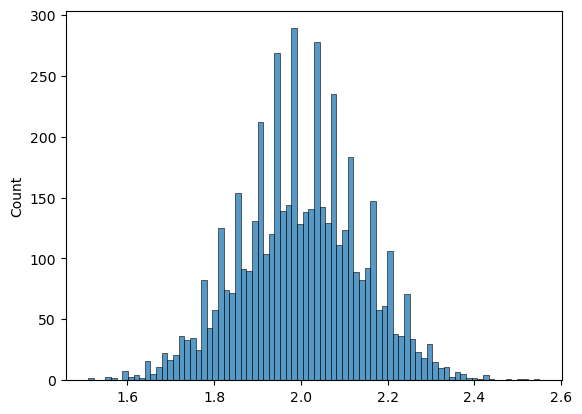

In [3]:
## Simulation in a loop

rng = np.random.default_rng( seed = 100 ) # Create a random number stream

K = 100
B = 5_000
result = []
for i in range(B):
    R = rng.integers( 0, 5, size = K ) 
    result.append(R)
result = np.array(result)
sns.histplot(result.mean(axis=1),
             bins=80)

<Axes: ylabel='Count'>

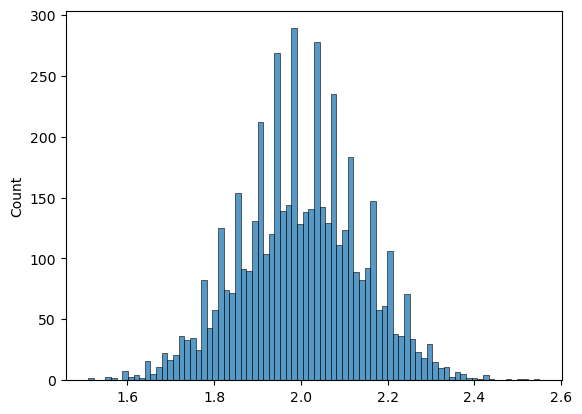

In [4]:
## Simulation in one line using Numpy
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

K = 100
B = 5_000

result  = rng.integers( 0, 5, size = (B,K) ) # Create a matrix of random values

sns.histplot(result.mean(axis=1), bins=80)

## Example 2: The Standard Normal

**Sample from the density:**
$$
\phi(z) = \dfrac{\exp\left\lbrace -z^2/2 \right\rbrace }{\sqrt{2 \pi}}
$$

<Axes: ylabel='Count'>

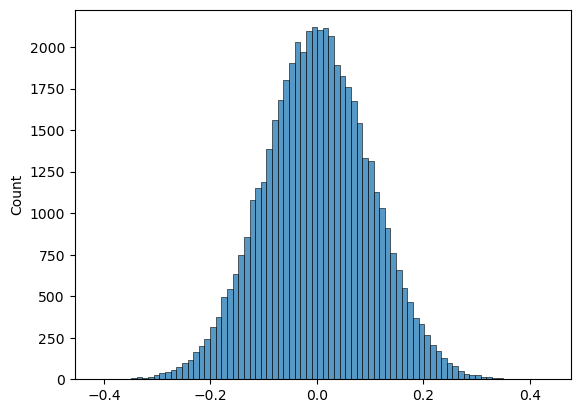

In [5]:
## Simulation in one line
rng = np.random.default_rng( seed = 100 ) # Create a random number stream

K = 100
B = 50_000

result  = rng.standard_normal( size = (B,K) ) 

sns.histplot(result.mean(axis=1), bins=80)

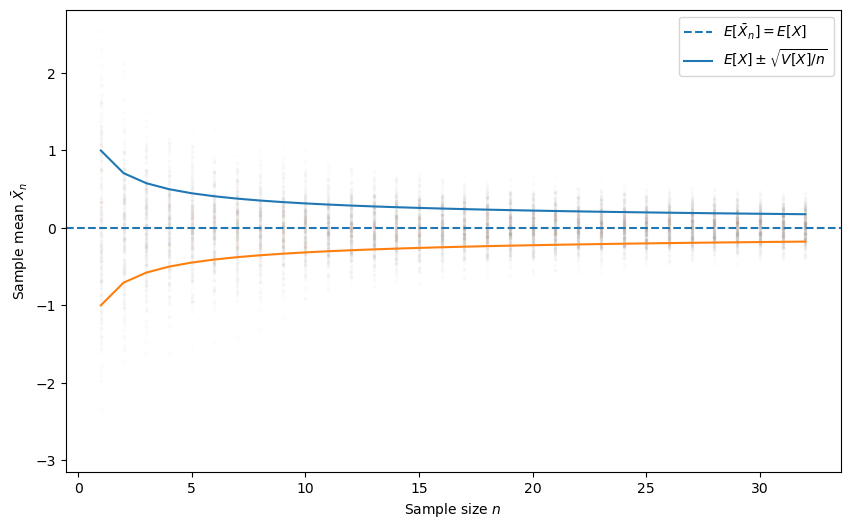

In [6]:
rng = np.random.default_rng(seed=100)

B = 5_000     # number of simulated experiments
N = 32       # maximum sample size

X = rng.standard_normal(size=(B, N))

# means[j, n-1] = mean of first n observations in experiment j
means = np.cumsum(X, axis=1) / np.arange(1, N + 1)
n = np.arange(1, N + 1)

plt.figure(figsize=(10, 6))

# plot a manageable subset of simulations
for j in range(300):
    plt.scatter(
        n,
        means[j],
        s=3,
        alpha=.01
    )

# theoretical mean
plt.axhline(0, linestyle="--", label=r"$E[\bar X_n] = E[X]$")

# theoretical ±1 SD
plt.plot(n,  1 / np.sqrt(n), label=r"$E[X] \pm \sqrt{V[X]/n}$")
plt.plot(n, -1 / np.sqrt(n))

plt.xlabel("Sample size $n$")
plt.ylabel(r"Sample mean $\bar X_n$")
plt.legend()
plt.show()

- What's the intuition of
$$
\mathbb{V}[\bar{X}_n] = \dfrac{\mathbb{V}[X]}{n}?
$$
- In a small sample, you can have a surprising number of extreme draws
- But as the sample gets large, it becomes "harder" to maintain a consistent number of extreme draws relative to the total number
- This causes the variance of the sample mean to shrink at a rate of $1/n$
- Large samples will have less variance, but it is "less likely" to have a large **proportion** of extreme draws in a large population than in a small one

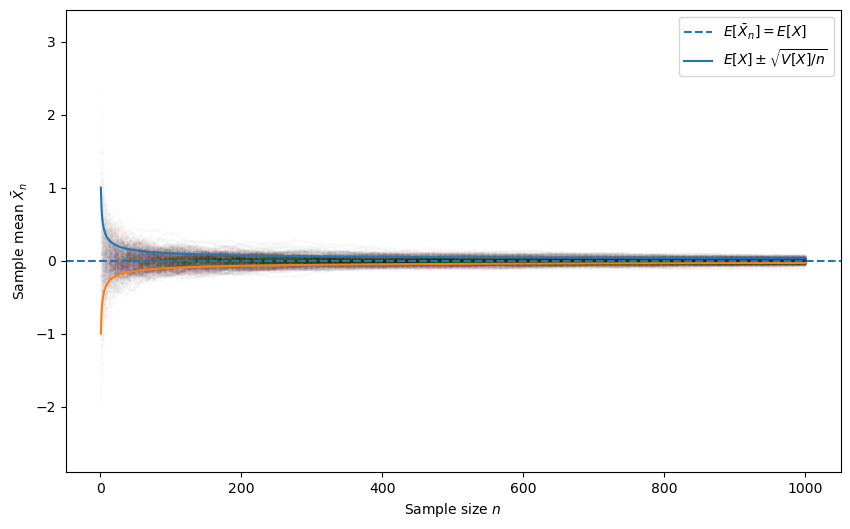

In [7]:
rng = np.random.default_rng(seed=100)

B = 5_000     # number of simulated experiments
N = 1_000       # maximum sample size

X = rng.standard_normal(size=(B, N))

# means[j, n-1] = mean of first n observations in experiment j
means = np.cumsum(X, axis=1) / np.arange(1, N + 1)
n = np.arange(1, N + 1)

plt.figure(figsize=(10, 6))

# plot a manageable subset of simulations
for j in range(300):
    plt.scatter(
        n,
        means[j],
        s=3,
        alpha=.005
    )

# theoretical mean
plt.axhline(0, linestyle="--", label=r"$E[\bar X_n] = E[X]$")

# theoretical ±1 SD
plt.plot(n,  1 / np.sqrt(n), label=r"$E[X] \pm \sqrt{V[X]/n}$")
plt.plot(n, -1 / np.sqrt(n))

plt.xlabel("Sample size $n$")
plt.ylabel(r"Sample mean $\bar X_n$")
plt.legend()
plt.show()

## Example 3: Choice

**Sample items from a list with a prescribed probability.**

In [8]:
cars = np.array([
    "Toyota",
    "Ford",
    "Chevrolet",
    "Honda",
    "Hyundai",
    "Nissan",
    "Kia",
    "GMC",
    "Subaru",
    "Jeep",
    "Other"
])

p = np.array([
    .138,
    .123,
    .108,
    .090,
    .058,
    .054,
    .053,
    .040,
    .039,
    .033,
    .264
])

In [9]:
rng = np.random.default_rng(seed=100)

rng.choice(cars, size=20, p=p)

array(['Other', 'Kia', 'Chevrolet', 'Toyota', 'Other', 'Kia', 'Other',
       'Other', 'Subaru', 'Ford', 'Other', 'Chevrolet', 'GMC', 'Kia',
       'Kia', 'Nissan', 'Other', 'Hyundai', 'Other', 'Hyundai'],
      dtype='<U9')

In [10]:
sample = rng.choice(cars, size=1000, p=p)

pd.Series(sample).value_counts(normalize=True)

Other        0.276
Ford         0.122
Chevrolet    0.118
Toyota       0.109
Honda        0.086
Kia          0.063
Hyundai      0.062
Nissan       0.054
Jeep         0.043
GMC          0.037
Subaru       0.030
Name: proportion, dtype: float64

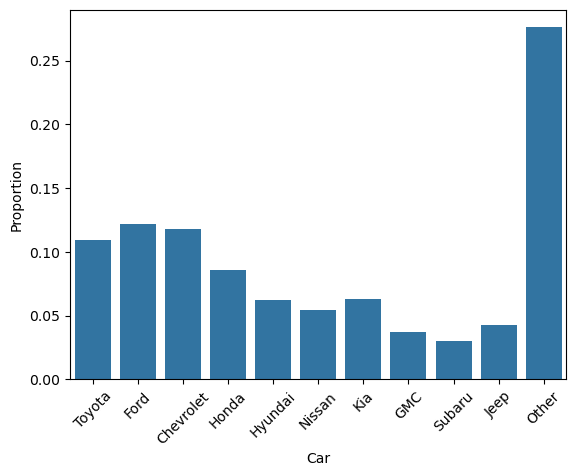

In [11]:
props = (
    pd.Series(sample)
      .value_counts(normalize=True)
      .reindex(cars)
      .reset_index()
)
props.columns = ["Car", "Proportion"]

sns.barplot(data=props,
    x="Car",
    y="Proportion")
plt.xticks(rotation=45)
plt.show()